In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [4]:
# generating synthetic nonlinear data

X = 6*np.random.rand(200,1)-3
y = 0.8*X**2+0.9*X+2+np.random.randn(200,1)

Text(0.5, 1.0, 'Synthetic Nonlinear Data')

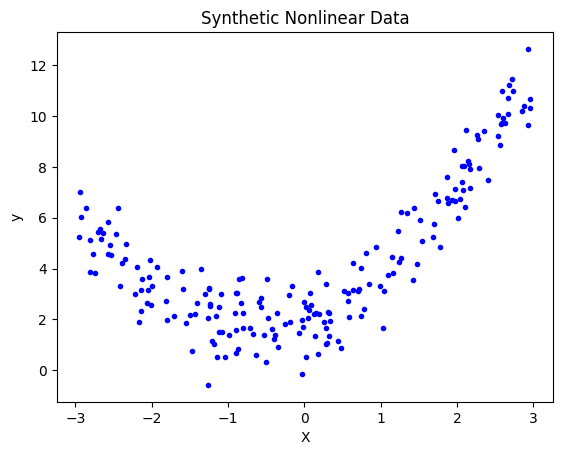

In [10]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Nonlinear Data')

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = lr.predict(X_test)
r2 = r2_score(y_test,y_pred)

In [16]:
r2

0.47607026021568233

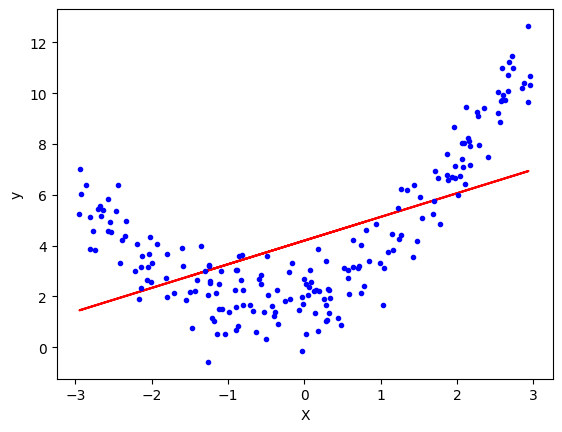

In [17]:
plt.plot(X_train,lr.predict(X_train),'r-')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [21]:
# Applying Polynomial linear regression
# degree=2

poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [22]:
print(X_train[0])
print(X_train_trans[0])

[-1.49739121]
[ 1.         -1.49739121  2.24218044]


In [23]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred1 = lr.predict(X_test_trans)

In [25]:
r2_score(y_test,y_pred1)

0.910014521348959

In [26]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.93708739 0.7872689 ]]
[2.02476392]


In [27]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

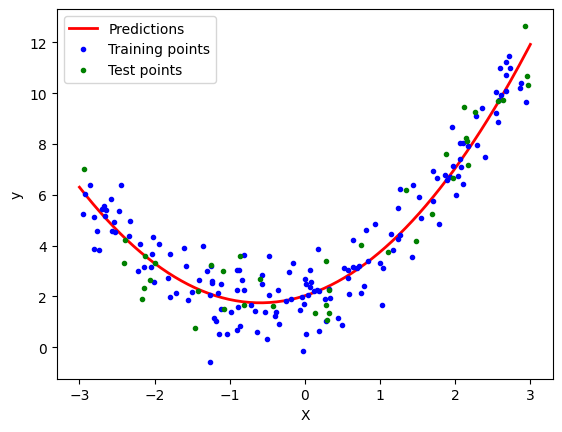

In [28]:
plt.plot(X_new,y_new,'r-',linewidth=2,label='Predictions')
plt.plot(X_train,y_train,'b.',label='Training points')
plt.plot(X_test,y_test,'g.',label='Test points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [29]:
# 3D Polynomial Regression

x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

In [31]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

In [33]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [34]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [35]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [39]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_multi_trans = poly.fit_transform(X_multi)